# Analise Venda

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Leitura de Dados

In [10]:
df = pd.read_excel("dados_vendas_brutos_corrigidos.xlsx", engine="openpyxl")

Visualização dos Dados

In [11]:
display(df.sample(10))
display(df.info())
display(df.dtypes)
display(df.isnull().sum())

,id_venda,data,loja,produto,categoria,quantidade,preco_unitario
4201,5201,2024-11-04,Loja Oeste,Calça Social,Vestuário Formal,2,153.51
2842,3842,2024-07-25,Loja Norte,Meias,Acessórios,14,13.98
2165,3165,2024-06-04,Loja Leste,Meias,Acessórios,18,14.89
1549,2549,2024-04-23,Loja Centro,Boné,Acessórios,2,71.28
4880,5880,2024-12-23,Loja Centro,Tênis Casual,Calçados Casual,4,255.06
3750,4750,2024-10-01,Loja Oeste,Jaqueta Esportiva,Vestuário Esportivo,1,291.09
4570,5570,2024-12-01,Loja Sul,Vestido,Vestuário Feminino,1,257.20
1956,2956,2024-05-23,Loja Centro,Camiseta Premium,Vestuário Premium,2,141.68
3268,4268,2024-08-25,Loja Norte,Camiseta Básica,Vestuário Básico,7,46.40
4605,5605,2024-12-03,Loja Norte,Calça Jeans,Vestuário Casual,5,195.98


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venda        5000 non-null   int64         
 1   data            5000 non-null   datetime64[us]
 2   loja            5000 non-null   str           
 3   produto         5000 non-null   str           
 4   categoria       5000 non-null   str           
 5   quantidade      5000 non-null   int64         
 6   preco_unitario  5000 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 273.6 KB


None

id_venda                   int64
data              datetime64[us]
loja                         str
produto                      str
categoria                    str
quantidade                 int64
preco_unitario           float64
dtype: object

id_venda          0
data              0
loja              0
produto           0
categoria         0
quantidade        0
preco_unitario    0
dtype: int64

Limpeza e Análise das Datas

In [12]:
df["data"] = pd.to_datetime(df["data"], errors="coerce")

df["nome_mes"] = df["data"].dt.month_name(locale="pt_BR")
df["nome_dia"] = df["data"].dt.day_name(locale="pt_BR")
df["mes_ano"] = df["data"].dt.to_period("M")

Enriquecimento da Coluna Valor Venda

In [13]:
df["valor_venda"] = df["quantidade"] * df["preco_unitario"]
df["valor_venda"] = df["valor_venda"].round(2)

Gráfico Produto Venda

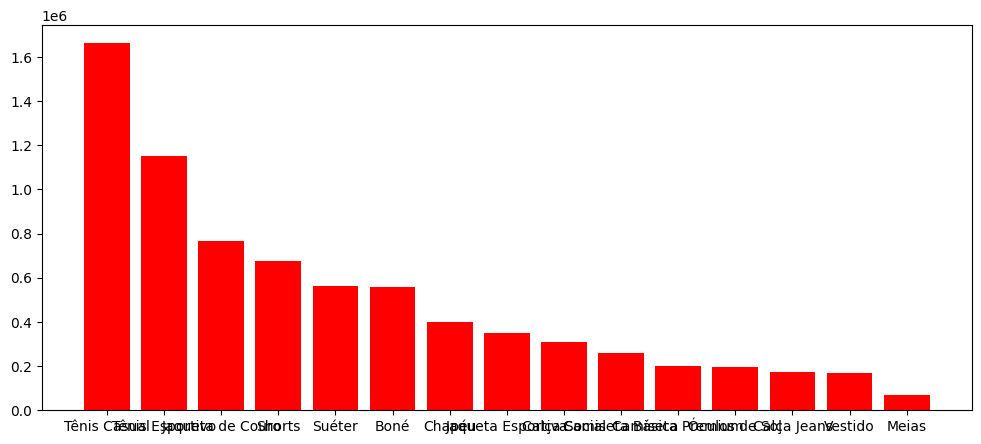

In [14]:
produto_venda = df.groupby("produto").agg(
    total_venda=("valor_venda", "sum")
).reset_index().sort_values("total_venda", ascending=False)

plt.figure(figsize=(12,5))

plt.bar(produto_venda["produto"], produto_venda["total_venda"], color="red")
plt.show()

Gráfico de Barras Faturamento por Loja

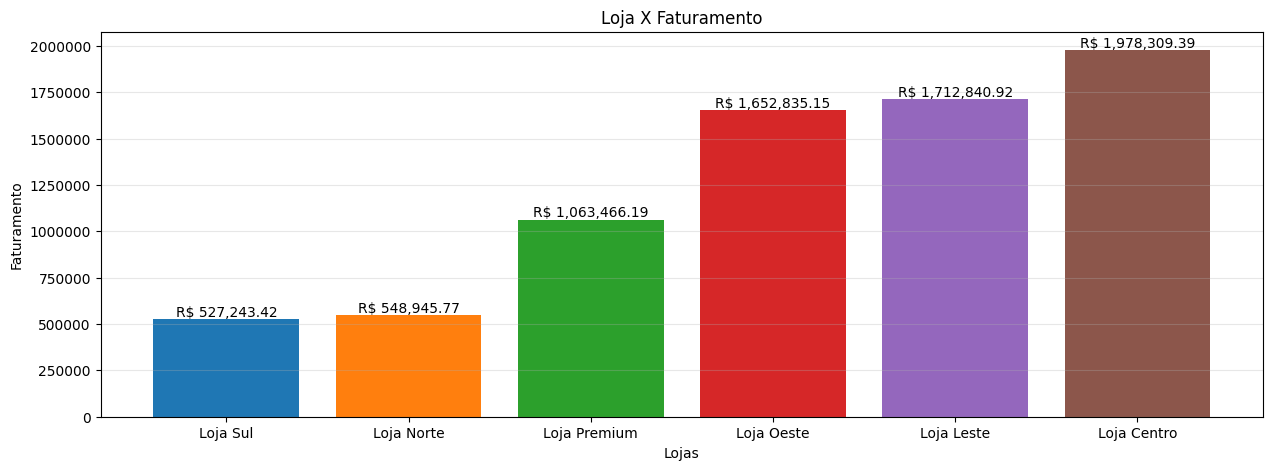

In [15]:
faturamento_loja = df.groupby("loja").agg(
    total_venda = ("valor_venda", "sum")
).reset_index().sort_values("total_venda", ascending=True)


cores = plt.cm.tab10(range(len(faturamento_loja["loja"])))

plt.figure(figsize=(15,5))

barras = plt.bar(faturamento_loja["loja"], faturamento_loja["total_venda"], color = cores)

plt.title("Loja X Faturamento")

plt.xlabel("Lojas")
plt.ylabel("Faturamento")

plt.ticklabel_format(style="plain", axis="y")

plt.grid(True, axis="y", alpha=0.3)


for bar in barras:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"R$ {bar.get_height():,.2f}",
        ha="center",
        va="bottom"
)


plt.show()

Gráfico de Pizza Dia da Semana x Faturamento

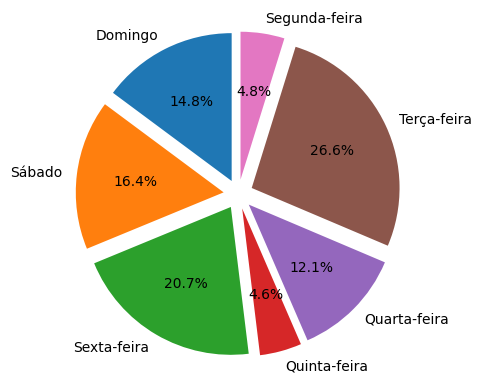

In [31]:
dia_faturamento = df.groupby("nome_dia").agg(
    total_venda=("valor_venda", "sum")
).reset_index()

dias_ordenado = ["Segunda-feira", "Terça-feira", "Quarta-feira", "Quinta-feira", "Sexta-feira", "Sábado", "Domingo"]

dia_faturamento["nome_dia"] = pd.Categorical(
    dia_faturamento["nome_dia"],
    categories=dias_ordenado,
    ordered=True
)

explode = [0.10] * len(dia_faturamento["nome_dia"])

dia_faturamento = dia_faturamento.sort_values("nome_dia", ascending=False)

plt.pie(dia_faturamento["total_venda"], labels=dia_faturamento["nome_dia"], autopct="%1.1f%%", startangle=90, explode=explode)

# plt.legend(
#     dia_faturamento["nome_dia"],
#     title="Dia da Semana",
#     loc="best"
# )

plt.show()